## 1. Imports

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

import torch
from torch.utils.data import DataLoader

from paths import TRAIN_PATH, VAL_PATH, TEST_PATH, CHECKPOINT_DIR

from amr_dataset import AMRDataset
from utils import (get_device, load_best_model, high_snr_confusion)

from viz import (plot_training_curves,
                 plot_accuracy_vs_snr_comparison,
                 accuracy_vs_snr_table,
                 collect_predictions,
                 plot_confusion_matrix,
                 plot_accuracy_vs_snr,
                 accuracy_vs_snr_table)

%matplotlib inline

## 2. Device Check and File Loading Checks

In [2]:
device = get_device()
print(f"Using device: {device}")

for name, p in [("train", TRAIN_PATH), ("val", VAL_PATH), ("test", TEST_PATH)]:
    print(f"{name}: {p} exists={p.exists()}")

Using device: cuda
train: /home/courier/luebeck/lub-amr/data/splits/train.h5 exists=True
val: /home/courier/luebeck/lub-amr/data/splits/val.h5 exists=True
test: /home/courier/luebeck/lub-amr/data/splits/test.h5 exists=True


## 3. Sanity Check for loading one batch

In [3]:
train_ds = AMRDataset(TRAIN_PATH, normalize="per_sample")
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

iq, mod_label, snr, domain = next(iter(train_loader))

print("iq shape:", iq.shape)
print("mod_label shape:", mod_label.shape)
print("snr shape:", snr.shape)
print("domain shape:", domain.shape)

iq shape: torch.Size([256, 2, 1024])
mod_label shape: torch.Size([256])
snr shape: torch.Size([256])
domain shape: torch.Size([256])


## 4. Baseline Training

In [4]:
from train import train_model
from models import BaselineCNN

history = train_model(
    model_cls   = BaselineCNN,
    run_name    = "baseline_pooled",
    epochs      = 20,
    batch_size  = 256,
    lr          = 1e-3,
    normalize   = "per_sample",
)

Using device: cuda
[baseline_pooled] epoch   1/20 train_loss=1.0475 train_acc=0.4986 val_loss=0.9088 val_acc=0.5715 (9.1s)
  -> saved new best checkpoint (val_acc=0.5715)
[baseline_pooled] epoch   2/20 train_loss=0.8799 train_acc=0.5717 val_loss=1.4376 val_acc=0.4456 (7.9s)
[baseline_pooled] epoch   3/20 train_loss=0.8261 train_acc=0.5934 val_loss=1.4008 val_acc=0.5206 (7.9s)
[baseline_pooled] epoch   4/20 train_loss=0.7991 train_acc=0.6036 val_loss=0.8037 val_acc=0.6010 (8.0s)
  -> saved new best checkpoint (val_acc=0.6010)
[baseline_pooled] epoch   5/20 train_loss=0.7800 train_acc=0.6117 val_loss=0.8775 val_acc=0.5831 (7.9s)
[baseline_pooled] epoch   6/20 train_loss=0.7644 train_acc=0.6188 val_loss=0.8761 val_acc=0.5547 (7.9s)
[baseline_pooled] epoch   7/20 train_loss=0.7514 train_acc=0.6235 val_loss=0.7679 val_acc=0.6273 (7.9s)
  -> saved new best checkpoint (val_acc=0.6273)
[baseline_pooled] epoch   8/20 train_loss=0.7393 train_acc=0.6291 val_loss=0.7387 val_acc=0.6338 (7.8s)
  -> 

## 5. Plotting 

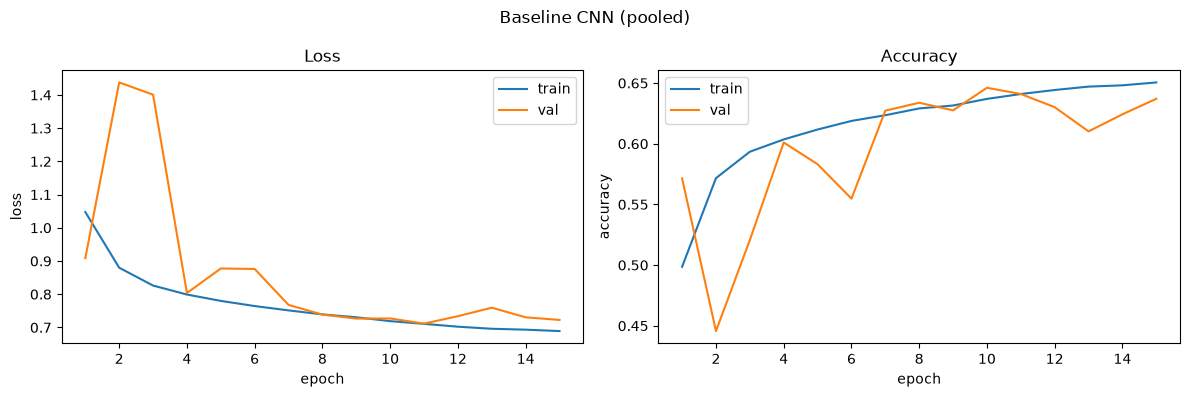

In [5]:
plot_training_curves(history, title = "Baseline CNN (pooled)");

## 6. Getting the best points from checkpoint dir

In [8]:
checkpoint_path = CHECKPOINT_DIR / "baseline_pooled_best.pt"
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

model = BaselineCNN().to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint['epoch']}, val_acc={checkpoint['val_acc']:.4f}")


Loaded checkpoint from epoch 10, val_acc=0.6461


## 7. Verification of test size

In [9]:
test_ds = AMRDataset(TEST_PATH, normalize="per_sample")
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

print(f"Test set size: {len(test_ds)}")

Test set size: 16384


## 8. Overall test accuracy

In [10]:
mod_true, mod_pred, snr, domain = collect_predictions(model, test_loader, device)

print("Overall test accuracy:", (mod_true == mod_pred).mean())

Overall test accuracy: 0.6448974609375


## 9. Confusion Matrix

<Axes: title={'center': 'Baseline CNN (pooled) — Test Confusion Matrix'}, xlabel='Predicted', ylabel='True'>

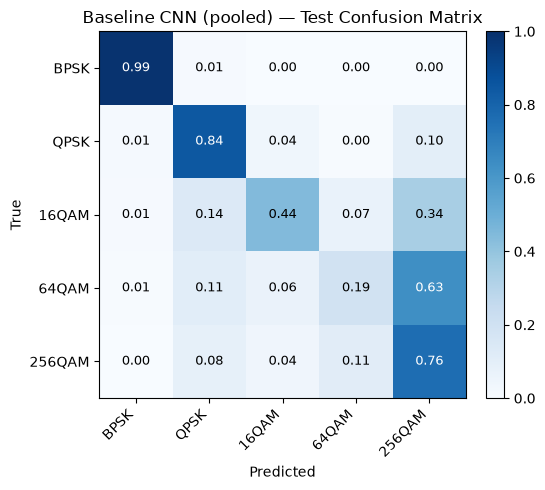

In [11]:
plot_confusion_matrix(mod_true, mod_pred, title="Baseline CNN (pooled) — Test Confusion Matrix")

## 10. Accuracy vs SNR

<Axes: title={'center': 'Baseline CNN (pooled) — Accuracy vs SNR'}, xlabel='SNR (dB)', ylabel='Accuracy'>

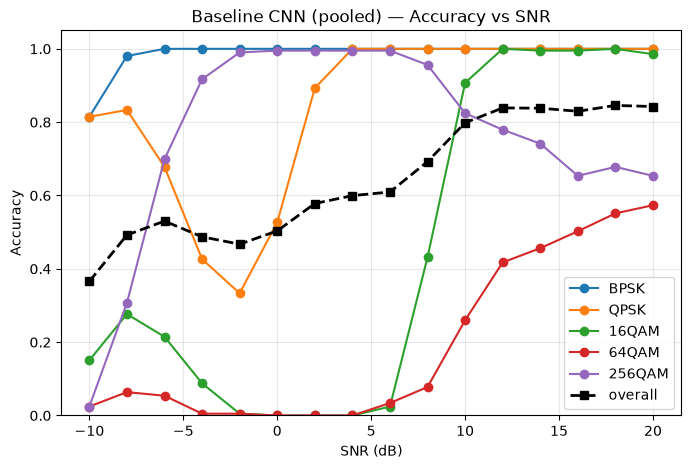

In [12]:
plot_accuracy_vs_snr(mod_true, mod_pred, snr, title="Baseline CNN (pooled) — Accuracy vs SNR")

## 10.5 Trying to debug the bad performance 

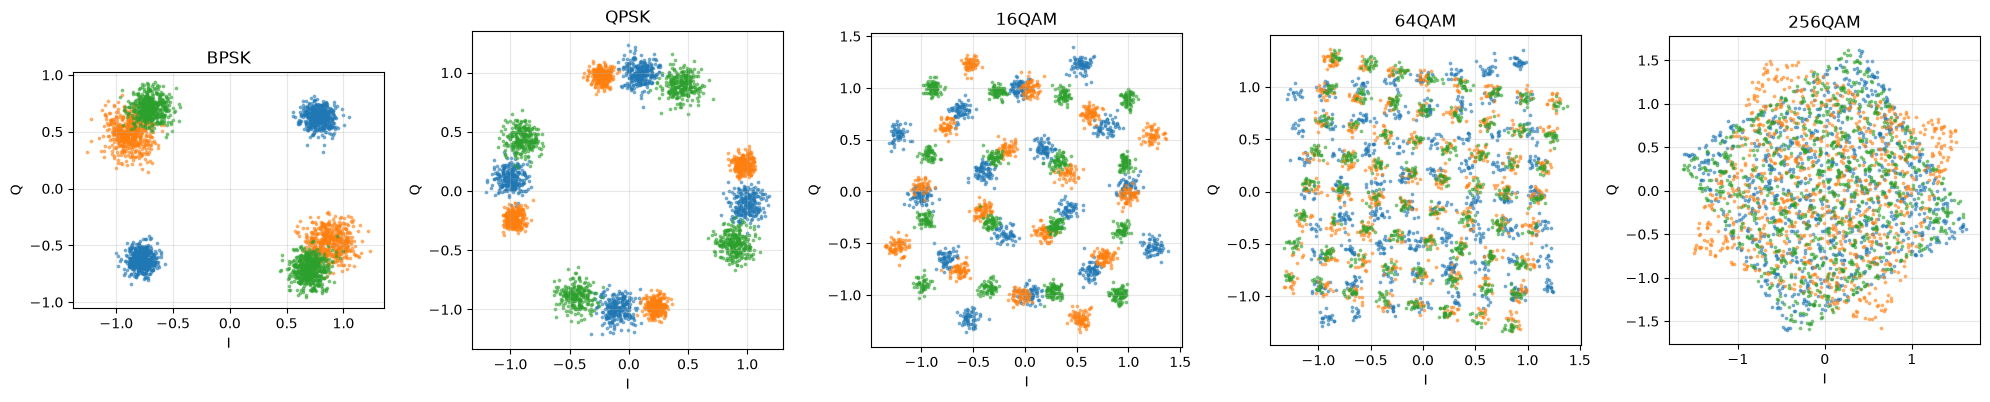

In [13]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from paths import TRAIN_PATH

MOD_NAMES = ['BPSK', 'QPSK', '16QAM', '64QAM', '256QAM']

with h5py.File(TRAIN_PATH, "r") as f:
    data = f["Data"][:]
    mods = f["Mods"][:].argmax(axis=1)
    snrs = f["SNRs"][:]

high_snr_mask = snrs >= 15

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, name in enumerate(MOD_NAMES):
    mask = high_snr_mask & (mods == i)
    idx = np.where(mask)[0][:3]  # first 3 high-SNR samples of this class
    for j in idx:
        row = data[j]
        axes[i].scatter(row.real, row.imag, s=3, alpha=0.5)
    axes[i].set_title(name)
    axes[i].set_xlabel("I")
    axes[i].set_ylabel("Q")
    axes[i].set_aspect("equal")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

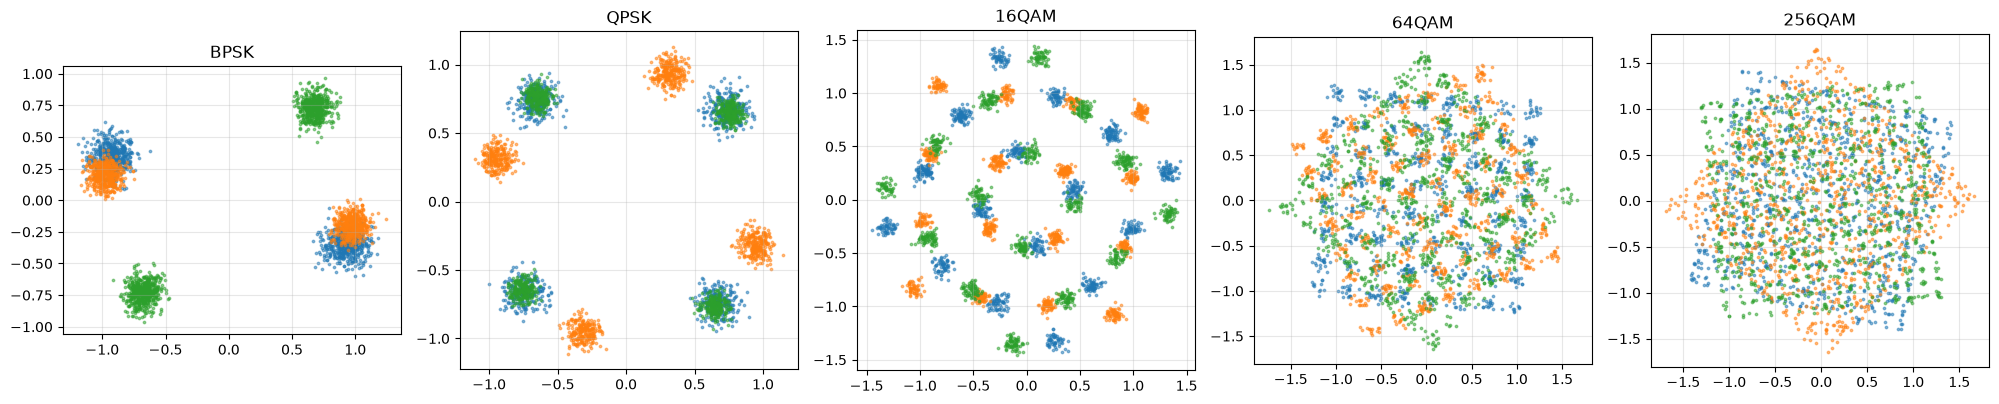

In [24]:
iq_batch, mod_batch, snr_batch, _ = next(iter(train_loader))
high_snr = snr_batch >= 15

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, name in enumerate(MOD_NAMES):
    mask = high_snr & (mod_batch == i)
    idx = torch.where(mask)[0][:3]
    for j in idx:
        row = iq_batch[j]  # (2, 1024): I, Q
        axes[i].scatter(row[0], row[1], s=3, alpha=0.5)
    axes[i].set_title(name)
    axes[i].set_aspect("equal")
    axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Baseline Comparison (RMa only)

In [14]:
history_rma = train_model(
    model_cls      = BaselineCNN,
    run_name       = "baseline_rma_only",
    epochs         = 20,
    batch_size     = 256,
    lr             = 1e-3,
    normalize      = "per_sample",
    domain_filter  = 0,  # Rma
)

Using device: cuda
[baseline_rma_only] epoch   1/20 train_loss=1.1385 train_acc=0.4567 val_loss=1.0142 val_acc=0.5067 (4.5s)
  -> saved new best checkpoint (val_acc=0.5067)
[baseline_rma_only] epoch   2/20 train_loss=0.9479 train_acc=0.5391 val_loss=1.3784 val_acc=0.4220 (4.1s)
[baseline_rma_only] epoch   3/20 train_loss=0.9017 train_acc=0.5647 val_loss=4.8031 val_acc=0.3461 (4.1s)
[baseline_rma_only] epoch   4/20 train_loss=0.8945 train_acc=0.5698 val_loss=1.7200 val_acc=0.4197 (4.1s)
[baseline_rma_only] epoch   5/20 train_loss=0.8705 train_acc=0.5806 val_loss=1.0610 val_acc=0.4877 (4.0s)
[baseline_rma_only] epoch   6/20 train_loss=0.8529 train_acc=0.5853 val_loss=1.2428 val_acc=0.4481 (4.1s)
  -> no improvement for 5 epochs, stopping early


## 12. Plotting for RMa Only

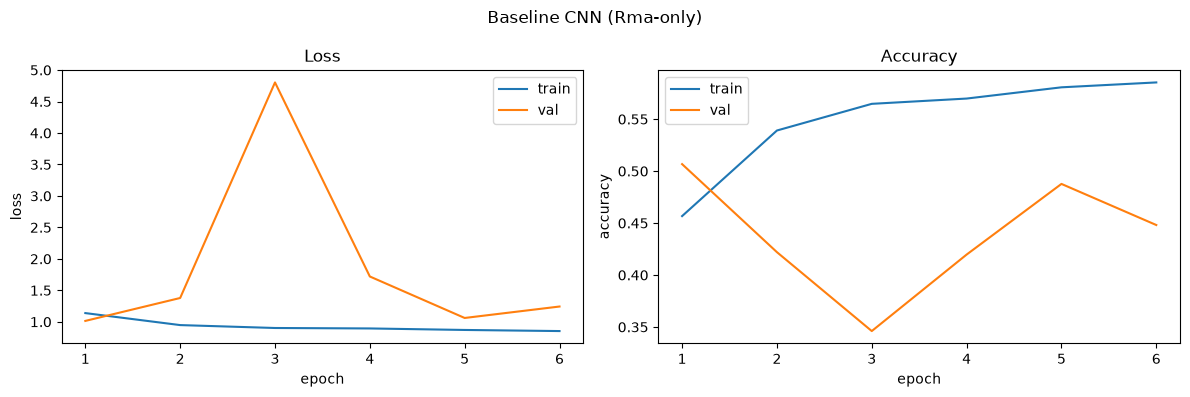

In [15]:
plot_training_curves(history_rma, title="Baseline CNN (Rma-only)");

## 13. Baseline Comparison (UMi only)

In [16]:
history_umi = train_model(
    model_cls      = BaselineCNN,
    run_name       = "baseline_umi_only",
    epochs         = 20,
    batch_size     = 256,
    lr             = 1e-3,
    normalize      = "per_sample",
    domain_filter  = 1,  # Umi
)

Using device: cuda
[baseline_umi_only] epoch   1/20 train_loss=1.1299 train_acc=0.4650 val_loss=1.1799 val_acc=0.4062 (4.6s)
  -> saved new best checkpoint (val_acc=0.4062)
[baseline_umi_only] epoch   2/20 train_loss=0.9377 train_acc=0.5527 val_loss=0.9040 val_acc=0.5804 (4.1s)
  -> saved new best checkpoint (val_acc=0.5804)
[baseline_umi_only] epoch   3/20 train_loss=0.9111 train_acc=0.5637 val_loss=0.9024 val_acc=0.5503 (4.1s)
[baseline_umi_only] epoch   4/20 train_loss=0.8935 train_acc=0.5700 val_loss=0.9395 val_acc=0.5497 (4.1s)
[baseline_umi_only] epoch   5/20 train_loss=0.8739 train_acc=0.5772 val_loss=0.9247 val_acc=0.5527 (4.1s)
[baseline_umi_only] epoch   6/20 train_loss=0.8542 train_acc=0.5814 val_loss=0.9182 val_acc=0.5459 (4.1s)
[baseline_umi_only] epoch   7/20 train_loss=0.8336 train_acc=0.5868 val_loss=1.4050 val_acc=0.4886 (4.1s)
  -> no improvement for 5 epochs, stopping early


## 14. Plotting for UMi Only

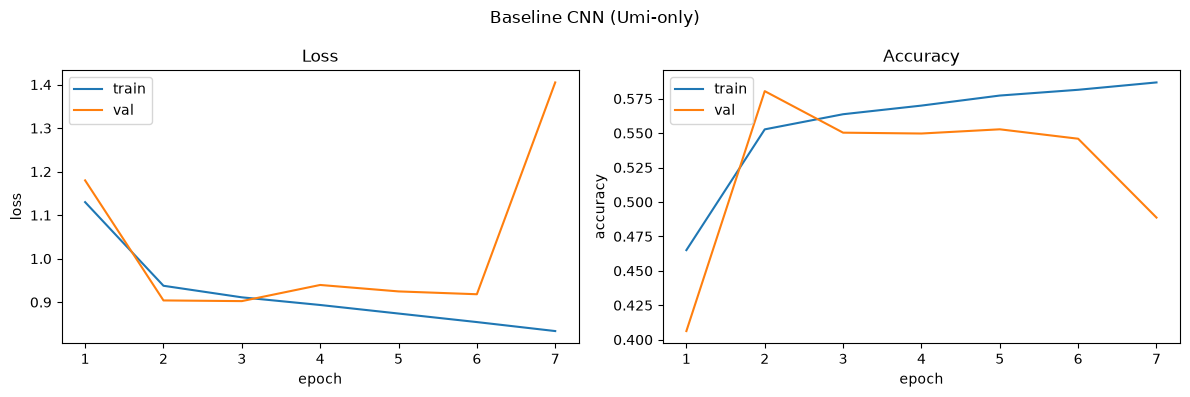

In [17]:
plot_training_curves(history_umi, title="Baseline CNN (Umi-only)");

## 15. Load RMa only and UMi Only for best checkpoints

In [23]:
model_rma = load_best_model("baseline_rma_only", device=device)
model_umi = load_best_model("baseline_umi_only", device=device, weights_only=False)

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray._reconstruct was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray._reconstruct])` or the `torch.serialization.safe_globals([numpy._core.multiarray._reconstruct])` context manager to allowlist this global if you trust this class/function.

Check the documentation of to

## 16. Evaluation of all three on the same fixed test.h5

In [ ]:
results = {
    "pooled":   collect_predictions(model,     test_loader, device)[:3],
    "rma_only": collect_predictions(model_rma, test_loader, device)[:3],
    "umi_only": collect_predictions(model_umi, test_loader, device)[:3],
}

for label, (mt, mp, _) in results.items():
    print(f"{label}: overall test accuracy = {(mt == mp).mean():.4f}")

pooled: overall test accuracy = 0.5358
rma_only: overall test accuracy = 0.5431
umi_only: overall test accuracy = 0.5226


## 17. Accuracy vs SNR - baseline comparison

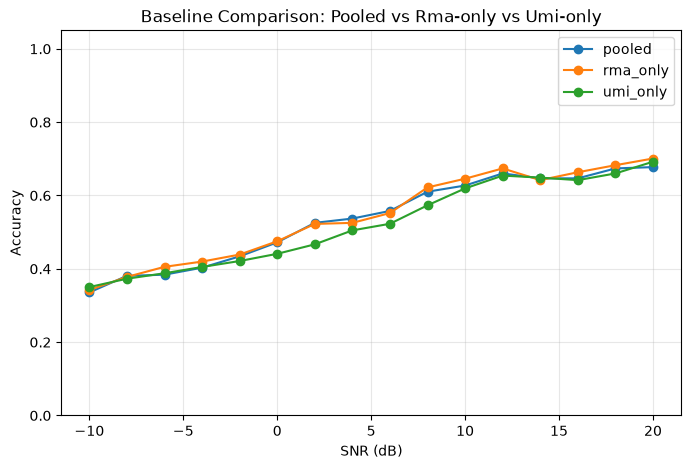

In [ ]:
plot_accuracy_vs_snr_comparison(
    results,
    title="Baseline Comparison: Pooled vs Rma-only vs Umi-only"
);

## 18. Confusion Matrices + accuracy vs SNR for rma only and umi only

<Axes: title={'center': 'Rma-only — Test Confusion Matrix'}, xlabel='Predicted', ylabel='True'>

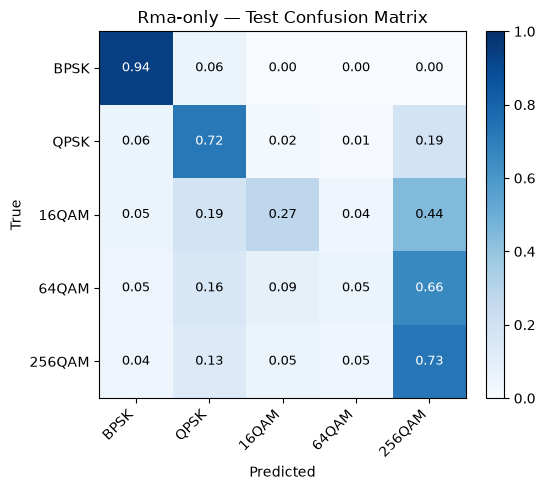

In [ ]:
mod_true_rma, mod_pred_rma, snr_rma = results["rma_only"]
mod_true_umi, mod_pred_umi, snr_umi = results["umi_only"]

plot_confusion_matrix(mod_true_rma, mod_pred_rma, title="Rma-only — Test Confusion Matrix")

<Axes: title={'center': 'Umi-only — Test Confusion Matrix'}, xlabel='Predicted', ylabel='True'>

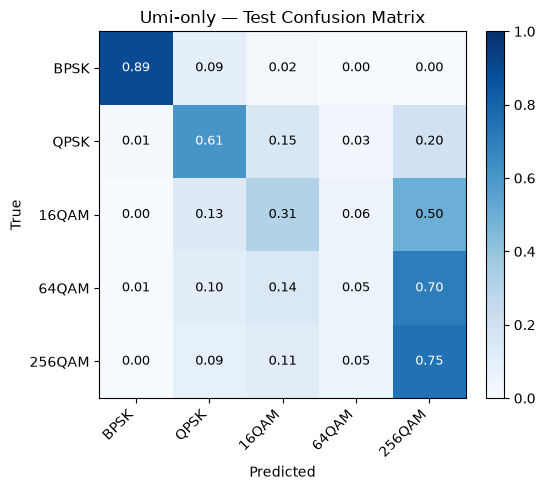

In [ ]:
plot_confusion_matrix(mod_true_umi, mod_pred_umi, title="Umi-only — Test Confusion Matrix")

<Axes: title={'center': 'Rma-only — Accuracy vs SNR'}, xlabel='SNR (dB)', ylabel='Accuracy'>

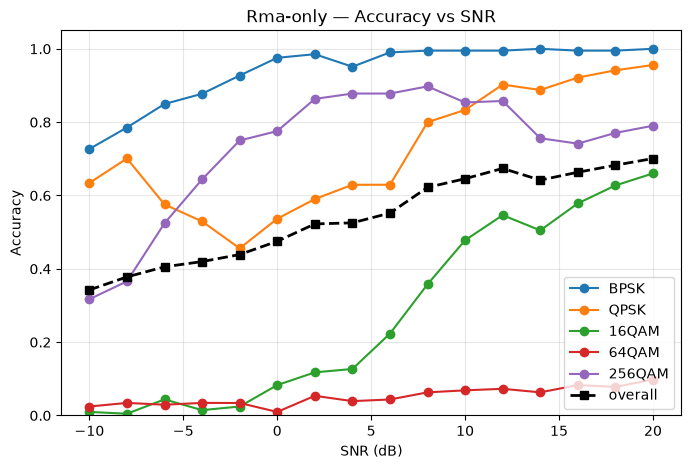

In [ ]:
plot_accuracy_vs_snr(mod_true_rma, mod_pred_rma, snr_rma, title="Rma-only — Accuracy vs SNR")

<Axes: title={'center': 'Umi-only — Accuracy vs SNR'}, xlabel='SNR (dB)', ylabel='Accuracy'>

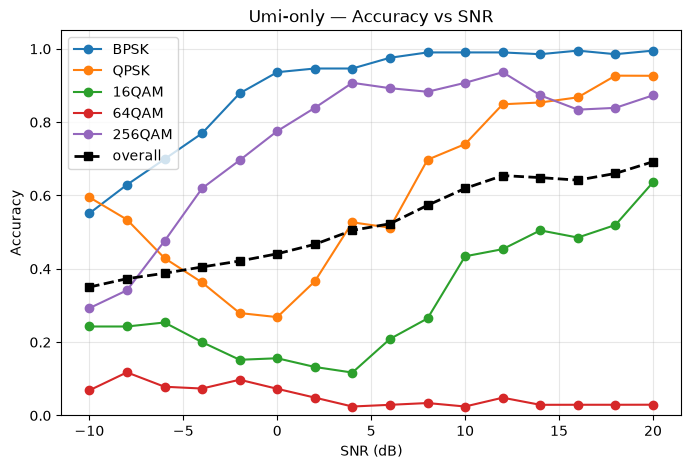

In [ ]:
plot_accuracy_vs_snr(mod_true_umi, mod_pred_umi, snr_umi, title="Umi-only — Accuracy vs SNR")

## 19. Numeric output - overall accuracy by SNR, all three side by side

In [ ]:
table_pooled = accuracy_vs_snr_table(*results["pooled"])
table_rma    = accuracy_vs_snr_table(*results["rma_only"])
table_umi    = accuracy_vs_snr_table(*results["umi_only"])

snr_levels = sorted(table_pooled["overall"].keys())

print(f"{'SNR':>6} | {'pooled':>8} | {'rma_only':>8} | {'umi_only':>8}")

for s in snr_levels:
    print(f"{s:6.1f} | {table_pooled['overall'][s]:8.3f} | {table_rma['overall'][s]:8.3f} | {table_umi['overall'][s]:8.3f}")

   SNR |   pooled | rma_only | umi_only
 -10.0 |    0.336 |    0.342 |    0.350
  -8.0 |    0.381 |    0.378 |    0.373
  -6.0 |    0.384 |    0.405 |    0.388
  -4.0 |    0.403 |    0.420 |    0.405
  -2.0 |    0.434 |    0.439 |    0.421
   0.0 |    0.472 |    0.475 |    0.441
   2.0 |    0.525 |    0.522 |    0.467
   4.0 |    0.537 |    0.525 |    0.505
   6.0 |    0.558 |    0.552 |    0.523
   8.0 |    0.610 |    0.622 |    0.573
  10.0 |    0.627 |    0.646 |    0.619
  12.0 |    0.660 |    0.674 |    0.654
  14.0 |    0.647 |    0.642 |    0.649
  16.0 |    0.647 |    0.663 |    0.642
  18.0 |    0.674 |    0.683 |    0.660
  20.0 |    0.677 |    0.701 |    0.692


In [ ]:
print("=== POOLED ===")

high_snr_confusion(*results["pooled"])

=== POOLED ===
n=3069 samples at SNR>=15.0
            BPSK    QPSK   16QAM   64QAM  256QAM
    BPSK   0.997   0.003   0.000   0.000   0.000
    QPSK   0.000   0.931   0.020   0.010   0.039
   16QAM   0.000   0.044   0.735   0.033   0.189
   64QAM   0.000   0.026   0.463   0.111   0.401
  256QAM   0.000   0.015   0.317   0.111   0.558


array([[0.99673736, 0.00326264, 0.        , 0.        , 0.        ],
       [0.        , 0.9314845 , 0.01957586, 0.00978793, 0.03915171],
       [0.        , 0.04397394, 0.73452769, 0.03257329, 0.18892508],
       [0.        , 0.02605863, 0.46254072, 0.11074919, 0.40065147],
       [0.        , 0.01463415, 0.31707317, 0.11056911, 0.55772358]])